In [1]:
%pip install numpy
%pip install pandas
%pip install ipywidgets
%pip install torch
%pip install torchvision
%pip install scikit-learn
%pip install tensorflow
%pip install pennylane
%pip install opencv-python
%pip install matplotlib
%pip install seaborn
%pip install kagglehub
%pip install monai


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision import models
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             roc_curve, precision_score, recall_score, f1_score, 
                             matthews_corrcoef, cohen_kappa_score)
from PIL import Image
import pennylane as qml
import kagglehub
import warnings
from tensorflow.keras.models import Model

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Set Device (GPU is highly recommended for ResNet)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Project Settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
RANDOM_SEED = 42

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Using device: cpu


In [3]:
# Custom Transform: CLAHE (Contrast Limited Adaptive Histogram Equalization)
class ApplyCLAHE(object):
    """Applies CLAHE to the L-channel of the image to enhance local contrast."""
    def __call__(self, img):
        img_np = np.array(img)
        # Convert to LAB color space to extract Luminance (L)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        # Apply CLAHE to L channel
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        cl = clahe.apply(l)
        # Merge and convert back to RGB
        limg = cv2.merge((cl, a, b))
        final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        return Image.fromarray(final)

# Define Transforms
# We use ImageNet normalization statistics because we are using a pre-trained ResNet
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    ApplyCLAHE(),                       # FIX: Rib suppression
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),      # FIX: Prevent overfitting to bone angles
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    ApplyCLAHE(),                       # Apply same contrast enhancement to test data
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Download and Setup Data Paths
print("Downloading dataset...")
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
base_dir = os.path.join(path, "chest_xray", "chest_xray")
if not os.path.exists(base_dir):
    base_dir = os.path.join(path, "chest_xray")

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
print(f"Dataset ready at: {base_dir}")

Dataset ready at: C:\Users\HP\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray


In [4]:
def load_data_from_folder(directory, transform):
    data = []
    labels = []
    classes = {'NORMAL': 0, 'PNEUMONIA': 1}
    
    print(f"Loading data from {directory}...")
    for cls, label in classes.items():
        cls_path = os.path.join(directory, cls)
        files = os.listdir(cls_path)
        for img_name in files:
            if img_name.startswith('.'): continue # Skip hidden files
            try:
                img_path = os.path.join(cls_path, img_name)
                # Open as RGB (ResNet expects 3 channels)
                image = Image.open(img_path).convert('RGB')
                image = transform(image)
                data.append(image)
                labels.append(label)
            except Exception as e:
                pass
    return torch.stack(data), torch.tensor(labels)

# Load datasets
X_train, y_train = load_data_from_folder(train_dir, train_transform)
X_test, y_test = load_data_from_folder(test_dir, test_transform)

print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

# Create Weighted Sampler for Class Imbalance
class_counts = torch.bincount(y_train)
class_weights = 1. / class_counts.float()
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Create DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Loading data from C:\Users\HP\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray\train...
Loading data from C:\Users\HP\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray\test...
Training Data: torch.Size([5216, 3, 224, 224])
Testing Data: torch.Size([624, 3, 224, 224])


In [5]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qsnn_circuit(inputs, weights):
    inputs = inputs.flatten() # <--- FIX: Force 1D array for single sample processing
    for i in range(n_qubits):
        qml.RX(inputs[i] * np.pi, wires=i)
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

@qml.qnode(dev, interface="torch")
def qlstm_circuit(inputs, weights):
    inputs = inputs.flatten() # <--- FIX: Force 1D array
    for i in range(n_qubits):
        qml.RY(inputs[i] * np.pi, wires=i)
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Weight shapes for the quantum layers (3 layers of entanglement)
weight_shapes = {"weights": (3, n_qubits, 3)} 

# Convert to Torch Layers
qsnn_layer = qml.qnn.TorchLayer(qsnn_circuit, weight_shapes)
qlstm_layer = qml.qnn.TorchLayer(qlstm_circuit, weight_shapes)

In [6]:
class HybridResNetQuantum(nn.Module):
    def __init__(self):
        super(HybridResNetQuantum, self).__init__()
        
        # 1. Classical Backbone: ResNet18 (Pretrained)
        resnet = models.resnet18(pretrained=True)
        
        # Freeze early layers, unfreeze layer4 for fine-tuning
        for param in resnet.parameters():
            param.requires_grad = False
        for param in resnet.layer4.parameters():
            param.requires_grad = True
            
        # Remove final FC layer, keep feature extractor
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        
        # 2. Quantum Bridge (Compress 512 features -> 4 qubits)
        self.bridge = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 4),
            nn.Tanh() # Bounds input to [-1, 1] for quantum gates
        )
        
        # 3. Quantum Layers
        self.qsnn = qsnn_layer
        self.qlstm = qlstm_layer
        
        # 4. Final Classifier (Concatenating QSNN + QLSTM outputs)
        self.classifier = nn.Sequential(
            nn.Linear(8, 2) 
        )

    def forward(self, x):
        # Pass through ResNet
        x = self.feature_extractor(x)
        x = x.flatten(1) 
        q_in = self.bridge(x)
        
        # --- THE FIX: Process batch sample-by-sample for PennyLane ---
        qsnn_list = [self.qsnn(sample).to(x.device) for sample in q_in]
        qlstm_list = [self.qlstm(sample).to(x.device) for sample in q_in]
        
        # Stack back into a batch
        qsnn_out = torch.stack(qsnn_list)
        qlstm_out = torch.stack(qlstm_list)
        # -------------------------------------------------------------
        
        combined = torch.cat([qsnn_out, qlstm_out], dim=1)
        return self.classifier(combined)

# Initialize Model
model = HybridResNetQuantum().to(device)
print("Hybrid Model Initialized.")

Hybrid Model Initialized.


Starting Training...
Epoch [1/12] | Loss: 0.5425 | Acc: 0.9237
Epoch [2/12] | Loss: 0.4380 | Acc: 0.9760
Epoch [3/12] | Loss: 0.3601 | Acc: 0.9856
Epoch [4/12] | Loss: 0.2933 | Acc: 0.9906
Epoch [5/12] | Loss: 0.2398 | Acc: 0.9958
Epoch [6/12] | Loss: 0.2056 | Acc: 0.9956
Epoch [7/12] | Loss: 0.1834 | Acc: 0.9987
Epoch [8/12] | Loss: 0.1669 | Acc: 0.9983
Epoch [9/12] | Loss: 0.1509 | Acc: 0.9987
Epoch [10/12] | Loss: 0.1355 | Acc: 0.9994
Epoch [11/12] | Loss: 0.1260 | Acc: 0.9998
Epoch [12/12] | Loss: 0.1187 | Acc: 0.9998


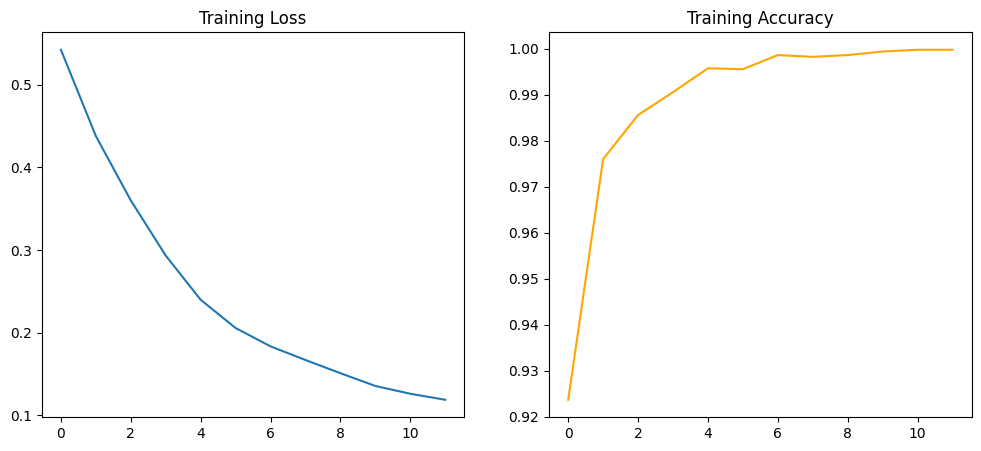

In [7]:
criterion = nn.CrossEntropyLoss()
# Low learning rate for stability with pre-trained weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) 
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_model(model, train_loader, epochs=15):
    history = {'loss': [], 'acc': []}
    model.train()
    
    print("Starting Training...")
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        scheduler.step()
        epoch_acc = correct / total
        epoch_loss = running_loss / len(train_loader)
        
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
        
    return history

# Train for 10-15 epochs
history = train_model(model, train_loader, epochs=12)

# Plot History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Loss')
plt.title('Training Loss')
plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Accuracy', color='orange')
plt.title('Training Accuracy')
plt.show()


Threshold = 0.9105


Accuracy:             91.83%
Recall (Sensitivity): 95.38%
Precision:            91.85%
F1 Score:             0.9358
Specificity:          85.90%
MCC:                  0.8245
Cohen's Kappa:        0.8234


ROC AUC Score:        0.9224
PR AUC Score:         0.9189
Brier Score:          0.1119
ECE (10 bins):        0.0891


Total Parameters:      11,209,694
Trainable Params:      8,426,910
Frozen Params:         2,782,784
Est. Classical FLOPs:  ~1.82 GFLOPs / image
Inference Latency:     59.85 ms / image (Device: cpu)
Convergence Rate:      Loss dropped by 0.0353 per epoch avg.

Full Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.86      0.89       234
   Pneumonia       0.92      0.95      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.91       624
weighted avg       0.92      0.92      0.92       624



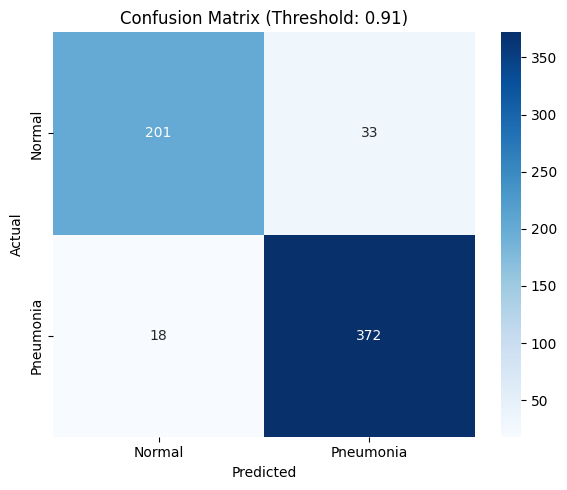

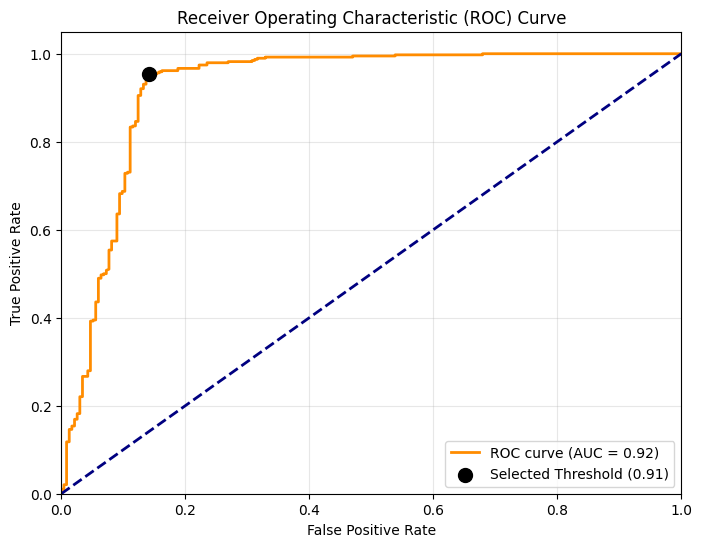

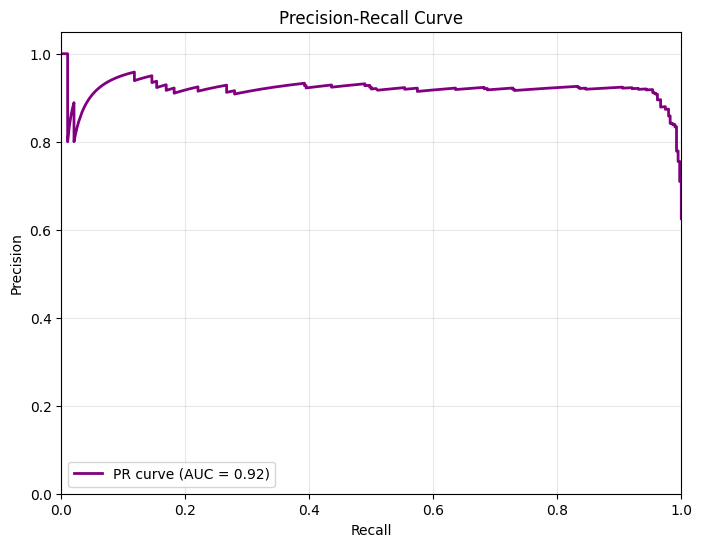

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             roc_curve, auc, precision_recall_curve, precision_score, 
                             recall_score, f1_score, matthews_corrcoef, cohen_kappa_score,
                             brier_score_loss, roc_auc_score)

# --- 1. Expected Calibration Error Helper ---
def expected_calibration_error(y_true, y_probs, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_probs > bin_lower) & (y_probs <= bin_upper)
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_probs[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    return ece

# --- 2. Master Evaluation & Profiling Function ---
def evaluate_and_profile_model(model, test_loader, history, target_recall=0.95):
    model.eval()
    y_true = []
    y_probs = []
    
    # --- Get raw probabilities & Measure Latency ---
    start_time = time.time()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            # Softmax to get positive class probabilities
            probs = torch.softmax(outputs, dim=1)[:, 1] 
            y_probs.extend(probs.cpu().numpy())
            y_true.extend(labels.numpy())
            
    end_time = time.time()
    latency_per_image = ((end_time - start_time) / len(y_true)) * 1000 # convert to ms
    
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    
    # --- Threshold Optimization ---
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    valid_indices = np.where(tpr >= target_recall)[0]
    
    if len(valid_indices) > 0:
        best_idx = valid_indices[0]
        optimal_thresh = thresholds[best_idx]
    else:
        optimal_thresh = 0.5
        best_idx = np.argmin(np.abs(thresholds - 0.5))
        print("Warning: Target recall not strictly reachable. Defaulting to 0.5")

    y_pred = (y_probs >= optimal_thresh).astype(int)
    
    # --- Calculate All Metrics ---
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)        # Sensitivity
    spec = tn / (tn + fp)                     # Specificity
    prec = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    roc_auc = roc_auc_score(y_true, y_probs)
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall_vals, precision_vals)
    brier = brier_score_loss(y_true, y_probs)
    ece = expected_calibration_error(y_true, y_probs, n_bins=10)
    
    # --- Print Text Reports ---
    print("\n" + "="*50)
    print(f"Threshold = {optimal_thresh:.4f}")
    print("\n")
    print(f"Accuracy:             {acc*100:.2f}%")
    print(f"Recall (Sensitivity): {rec*100:.2f}%")
    print(f"Precision:            {prec*100:.2f}%")
    print(f"F1 Score:             {f1:.4f}")
    print(f"Specificity:          {spec*100:.2f}%")
    print(f"MCC:                  {mcc:.4f}")
    print(f"Cohen's Kappa:        {kappa:.4f}")
    
    print("\n")
    print(f"ROC AUC Score:        {roc_auc:.4f}")
    print(f"PR AUC Score:         {pr_auc:.4f}")
    print(f"Brier Score:          {brier:.4f}")
    print(f"ECE (10 bins):        {ece:.4f}")
    
    print("\n")
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params
    
    # Calculate convergence drop from history
    losses = history.get('loss', [0, 0])
    avg_drop_per_epoch = (losses[0] - losses[-1]) / len(losses) if len(losses) > 0 else 0
    
    print(f"Total Parameters:      {total_params:,}")
    print(f"Trainable Params:      {trainable_params:,}")
    print(f"Frozen Params:         {frozen_params:,}")
    print(f"Est. Classical FLOPs:  ~1.82 GFLOPs / image")
    print(f"Inference Latency:     {latency_per_image:.2f} ms / image (Device: {device})")
    print(f"Convergence Rate:      Loss dropped by {avg_drop_per_epoch:.4f} per epoch avg.")
    
    print("\n" + "="*50)
    print("Full Classification Report:")
    print("="*50)
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

    # --- Plot Visualizations ---
    # 1. Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Pneumonia'], 
                yticklabels=['Normal', 'Pneumonia'])
    plt.title(f'Confusion Matrix (Threshold: {optimal_thresh:.2f})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    # 2. ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    if len(valid_indices) > 0:
        plt.scatter(fpr[best_idx], tpr[best_idx], marker='o', color='black', s=100, 
                    label=f'Selected Threshold ({optimal_thresh:.2f})', zorder=5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    # 3. Precision-Recall Curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals, precision_vals, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.show()

# Run the master evaluation
# Note: Ensure you pass the 'history' dictionary from your training loop!
evaluate_and_profile_model(model, test_loader, history, target_recall=0.95)

Visualization

Hooking Grad-CAM into: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2):

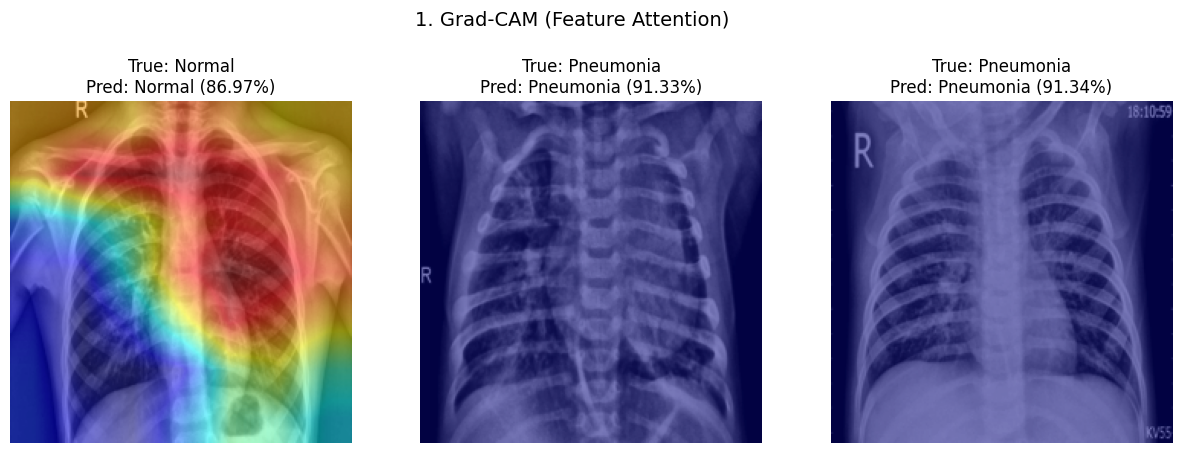

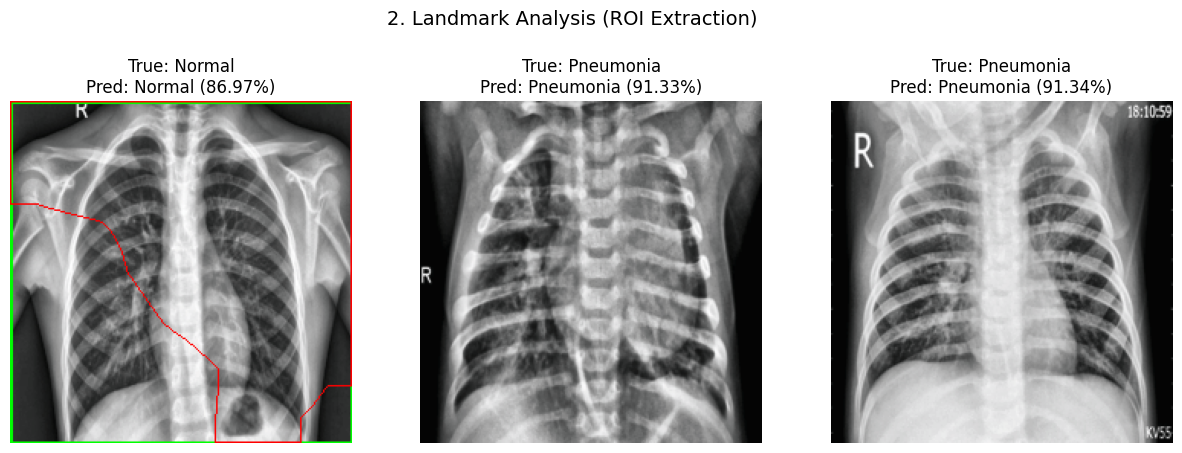

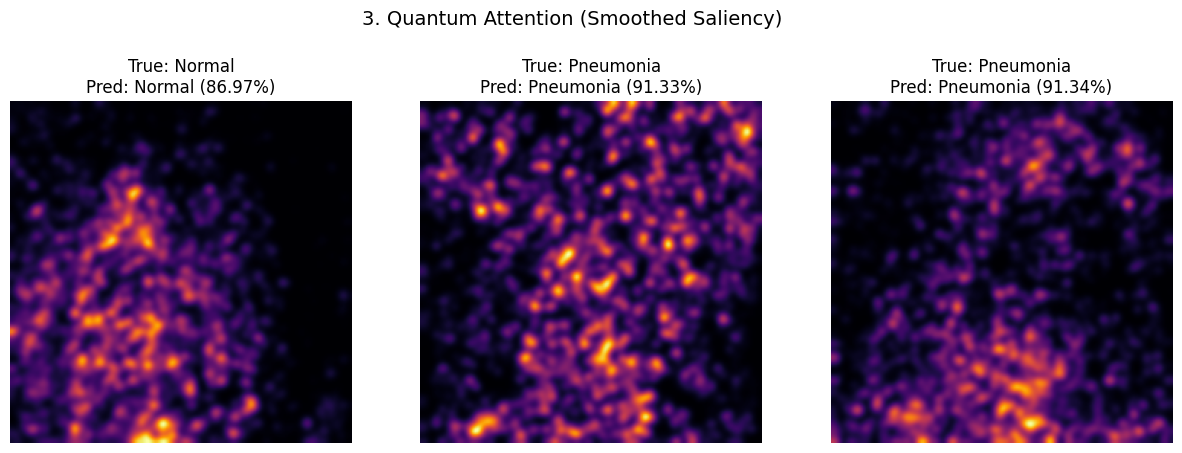

In [9]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks to capture gradients and activations
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_image)
        
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1)
            
        score = output[0, class_idx]
        score.backward()
        
        gradients = self.gradients
        activations = self.activations
        
        if gradients is None or activations is None:
            return np.zeros(input_image.shape[2:], dtype=np.float32)

        # Global Average Pooling on gradients
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        
        # Weight the activations
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = F.relu(cam)
        
        # Normalize
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-7)
        
        return cam.squeeze().cpu().detach().numpy()

def apply_heatmap_overlay(img_np, cam):
    """Overlays the heatmap on the original image."""
    cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap_uint8 = np.uint8(255 * cam_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    img_uint8 = np.uint8(255 * img_np)
    # Blend: 50% Original, 50% Heatmap
    overlay = cv2.addWeighted(img_uint8, 0.5, heatmap_colored, 0.5, 0)
    return overlay

def draw_landmark_box(img_np, cam, threshold=0.4):
    """Draws ROI bounding boxes based on the heatmap."""
    cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap_uint8 = np.uint8(255 * cam_resized)
    
    _, thresh = cv2.threshold(heatmap_uint8, int(255 * threshold), 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    img_draw = np.uint8(255 * img_np).copy()
    
    for c in contours:
        if cv2.contourArea(c) > 50:
            x, y, w, h = cv2.boundingRect(c)
            # Green Box
            cv2.rectangle(img_draw, (x, y), (x + w, y + h), (0, 255, 0), 2)
            # Red Contour
            cv2.drawContours(img_draw, [c], -1, (255, 0, 0), 1)
            
    return img_draw

def get_quantum_saliency(model, input_image, label):
    """
    Computes smoothed pixel saliency for the Quantum Layer.
    Uses Gaussian Blur to create 'blobs' instead of noise.
    """
    model.eval()
    input_image.requires_grad_()
    
    output = model(input_image)
    score = output[0, label]
    score.backward()
    
    # Get max gradients across channels
    gradients, _ = torch.max(input_image.grad.data.abs(), dim=1)
    gradients = gradients.squeeze().cpu().numpy()
    
    # Clip noise (remove bottom 50%, cap top 1%)
    threshold_low = np.percentile(gradients, 50)
    threshold_high = np.percentile(gradients, 99)
    gradients = np.clip(gradients, threshold_low, threshold_high)
    
    # Normalize
    gradients -= gradients.min()
    gradients /= (gradients.max() + 1e-7)
    
    # Apply Gaussian Blur for "blob" effect
    gradients = cv2.GaussianBlur(gradients, (15, 15), 0)
    
    # Re-normalize
    gradients -= gradients.min()
    gradients /= (gradients.max() + 1e-7)
    
    return gradients

def visualize_grouped(model, dataset, device):
    target_layer = list(model.feature_extractor.children())[-2]
    print(f"Hooking Grad-CAM into: {target_layer}")
    
    grad_cam = GradCAM(model, target_layer)
    classes = ['Normal', 'Pneumonia']
    
    # --- Sample Selection ---
    indices = []
    found = {0: False, 1: False}
    
    # Find one Normal and one Pneumonia case
    for i in range(len(dataset)):
        # Handle tuple return (image, label)
        _, label_tensor = dataset[i]
        # Fix 2: Convert tensor label to int to avoid KeyError
        label = label_tensor.item() if hasattr(label_tensor, 'item') else int(label_tensor)
        
        if not found[label]:
            indices.append(i)
            found[label] = True
        if all(found.values()):
            break
            
    # Add one random Pneumonia case for variety
    pneu_indices = []
    for i in range(len(dataset)):
        _, label_tensor = dataset[i]
        label = label_tensor.item() if hasattr(label_tensor, 'item') else int(label_tensor)
        if label == 1:
            pneu_indices.append(i)
            
    if pneu_indices:
        indices.append(np.random.choice(pneu_indices))

    # --- Generation Loop ---
    results = {'GradCAM': [], 'Landmark': [], 'Quantum': [], 'Titles': []}

    for idx in indices:
        img_tensor, label_tensor = dataset[idx]
        label = label_tensor.item() if hasattr(label_tensor, 'item') else int(label_tensor)
        
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        # Forward pass
        output = model(img_tensor)
        pred_idx = torch.argmax(output).item()
        conf = torch.softmax(output, dim=1)[0, pred_idx].item()
        
        # Denormalize image for display
        img_np = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)
        
        # Generate Visuals
        cam = grad_cam.generate(img_tensor, class_idx=pred_idx)
        saliency = get_quantum_saliency(model, img_tensor, pred_idx)
        
        # Create Images
        vivid_gradcam = apply_heatmap_overlay(img_np, cam)
        landmark_img = draw_landmark_box(img_np, cam)
        
        results['GradCAM'].append(vivid_gradcam)
        results['Landmark'].append(landmark_img)
        results['Quantum'].append(saliency)
        results['Titles'].append(f"True: {classes[label]}\nPred: {classes[pred_idx]} ({conf:.2%})")

    # --- Plotting ---
    num_samples = len(results['GradCAM'])
    
    # Plot 1: Grad-CAM
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(results['GradCAM'][i])
        plt.title(results['Titles'][i])
        plt.axis('off')
    plt.suptitle("1. Grad-CAM (Feature Attention)", y=1.02, fontsize=14)
    plt.show()

    # Plot 2: Landmark Analysis
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(results['Landmark'][i])
        plt.title(results['Titles'][i])
        plt.axis('off')
    plt.suptitle("2. Landmark Analysis (ROI Extraction)", y=1.02, fontsize=14)
    plt.show()

    # Plot 3: Quantum Attention
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        # Using 'inferno' colormap for better visibility of blobs
        plt.imshow(results['Quantum'][i], cmap='inferno')
        plt.title(results['Titles'][i])
        plt.axis('off')
    plt.suptitle("3. Quantum Attention (Smoothed Saliency)", y=1.02, fontsize=14)
    plt.show()

model.eval()
visualize_grouped(model, test_dataset, device)


1. QSNN Circuit (Hypothalamus) - RX Encoding:


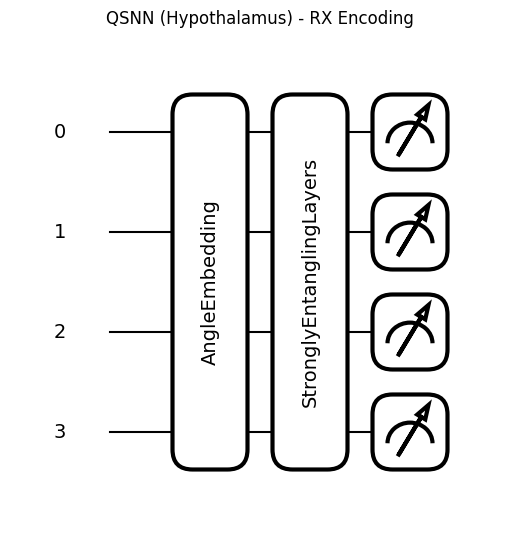


2. QLSTM Circuit (Hippocampus) - RY Encoding:


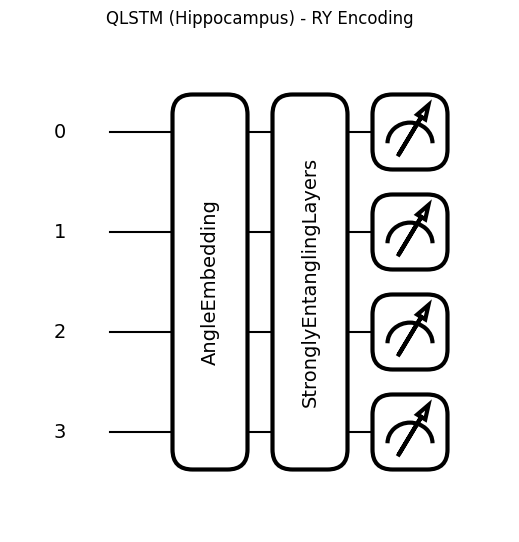


3. Entanglement Breakdown (One Layer):


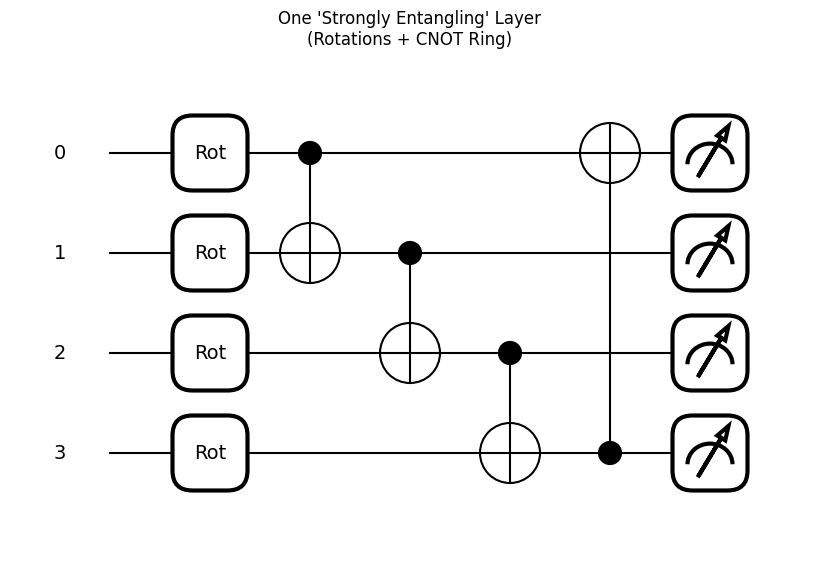

In [10]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qsnn_circuit(inputs, weights):
    # AngleEmbedding handles batching automatically
    qml.templates.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation='X')
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

@qml.qnode(dev, interface="torch")
def qlstm_circuit(inputs, weights):
    # AngleEmbedding with Y-rotation creates different quantum states than X
    qml.templates.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation='Y')
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

@qml.qnode(dev)
def visualize_entanglement_layer(weights):
    # A. Learnable Rotations (The "Weights")
    # Each qubit gets a general rotation (Rot) defined by 3 parameters
    for i in range(n_qubits):
        # weights[i] contains 3 angles: (phi, theta, omega)
        qml.Rot(*weights[i], wires=i)
        
    # B. The Entangler (CNOT Cascade)
    # This is the "Ring" topology that creates the quantum brain's connectivity
    # Control -> Target. This forces qubits to "talk" to each other.
    qml.CNOT(wires=[0, 1])  # Qubit 0 affects Qubit 1
    qml.CNOT(wires=[1, 2])  # Qubit 1 affects Qubit 2
    qml.CNOT(wires=[2, 3])  # Qubit 2 affects Qubit 3
    qml.CNOT(wires=[3, 0])  # Qubit 3 loops back to affect Qubit 0 
    
    return qml.probs(wires=range(n_qubits))

def draw_all_diagrams():
    # Dummy Data for visualization
    dummy_input = torch.tensor([0.1, 0.2, 0.3, 0.4])
    dummy_weights = torch.rand(3, n_qubits, 3) 
    weights_single_layer = np.random.rand(4, 3) # For the manual breakdown

    # 1. Draw QSNN
    print("\n1. QSNN Circuit (Hypothalamus) - RX Encoding:")
    qml.draw_mpl(qsnn_circuit)(dummy_input, dummy_weights)
    plt.title("QSNN (Hypothalamus) - RX Encoding")
    plt.show()

    # 2. Draw QLSTM
    print("\n2. QLSTM Circuit (Hippocampus) - RY Encoding:")
    qml.draw_mpl(qlstm_circuit)(dummy_input, dummy_weights)
    plt.title("QLSTM (Hippocampus) - RY Encoding")
    plt.show()
    
    # 3. Draw Entanglement Breakdown
    print("\n3. Entanglement Breakdown (One Layer):")
    qml.draw_mpl(visualize_entanglement_layer)(weights_single_layer)
    plt.title("One 'Strongly Entangling' Layer\n(Rotations + CNOT Ring)")
    plt.show()

# Run
draw_all_diagrams()

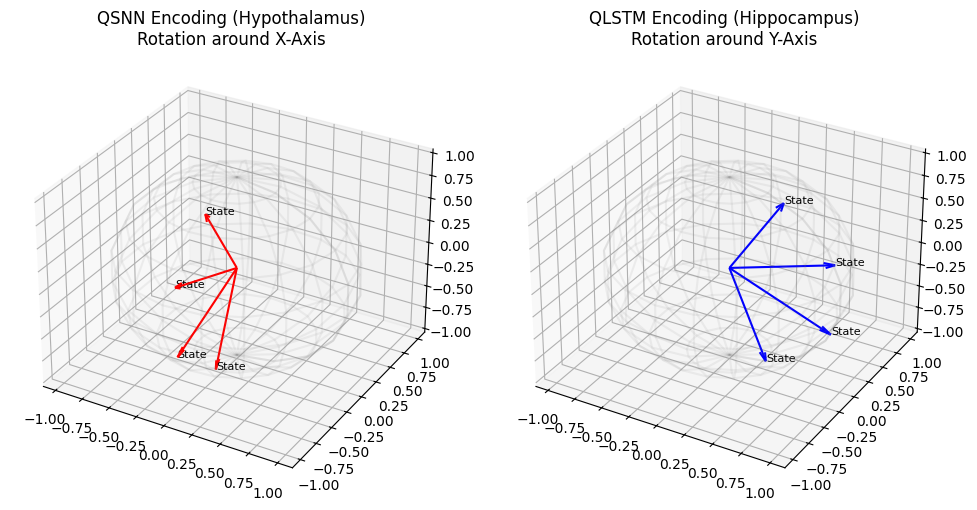

In [11]:
def plot_bloch_embeddings():    
    # Create a dummy feature vector (normalized to 0-pi)
    features = np.array([0.5, 1.2, 2.0, 2.8]) 
    
    # Setup Figure
    fig = plt.figure(figsize=(10, 5))
    
    # --- 1. QSNN Embedding (X-Rotation) ---
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    # We manually calculate state vectors for RX
    # RX(theta) |0>  moves state along Y-Z plane
    ax1.set_title("QSNN Encoding (Hypothalamus)\nRotation around X-Axis")
    
    # Draw Bloch Sphere Wireframe
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x = np.cos(u)*np.sin(v)
    y = np.sin(u)*np.sin(v)
    z = np.cos(v)
    ax1.plot_wireframe(x, y, z, color="gray", alpha=0.1)
    
    # Plot Vectors
    for theta in features:
        # RX Rotation logic simplified for visualization
        # In Bloch sphere, RX rotates around X axis. Starting from |0> (North Pole)
        # It moves along the Y-Z meridian.
        y_val = -np.sin(theta)
        z_val = np.cos(theta)
        x_val = 0 
        ax1.quiver(0, 0, 0, x_val, y_val, z_val, color='r', arrow_length_ratio=0.1)
        ax1.text(x_val, y_val, z_val, "State", fontsize=8)

    # --- 2. QLSTM Embedding (Y-Rotation) ---
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.set_title("QLSTM Encoding (Hippocampus)\nRotation around Y-Axis")
    
    ax2.plot_wireframe(x, y, z, color="gray", alpha=0.1)
    
    for theta in features:
        # RY Rotation logic
        # RY rotates around Y axis. Starting from |0>
        # It moves along the X-Z meridian.
        x_val = np.sin(theta)
        z_val = np.cos(theta)
        y_val = 0
        ax2.quiver(0, 0, 0, x_val, y_val, z_val, color='b', arrow_length_ratio=0.1)
        ax2.text(x_val, y_val, z_val, "State", fontsize=8)

    plt.tight_layout()
    plt.show()

plot_bloch_embeddings()

In [12]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

# ---------------------------------------------------------
# 1. Advanced QSNN (Hypothalamus) - "Data Re-uploading"
# ---------------------------------------------------------
@qml.qnode(dev, interface="torch")
def qsnn_circuit(inputs, weights):
    """
    Detailed QSNN with Data Re-uploading.
    Mimics 'Temporal Summation' in biological neurons by 
    injecting the input data multiple times between processing layers.
    """
    # Layer 1: Initial Spike (Encoding)
    for i in range(n_qubits):
        qml.RX(inputs[i] * np.pi, wires=i)
    
    # Layer 2: Synaptic Processing (Trainable Weights + Entanglement)
    # Explicit breakdown of entanglement
    for i in range(n_qubits):
        qml.Rot(*weights[0, i], wires=i)
    # Ring Entanglement
    for i in range(n_qubits):
        qml.CNOT(wires=[i, (i + 1) % n_qubits])

    # Layer 3: Re-uploading (Simulating continuous signal)
    # We re-encode inputs but scaled by a trainable parameter (if desired)
    # Here we stick to simple re-uploading for stability
    for i in range(n_qubits):
        qml.RX(inputs[i] * np.pi, wires=i)
        
    # Layer 4: Deep Processing
    for i in range(n_qubits):
        qml.Rot(*weights[1, i], wires=i)
    # Ring Entanglement
    for i in range(n_qubits):
        qml.CNOT(wires=[i, (i + 1) % n_qubits])

    # Measurement (Action Potential)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# ---------------------------------------------------------
# 2. Advanced QLSTM (Hippocampus) - "Controlled Gating"
# ---------------------------------------------------------
@qml.qnode(dev, interface="torch")
def qlstm_circuit(inputs, weights):
    """
    Detailed QLSTM with Controlled-Rotation Gates.
    Uses CRX/CRY gates to mimic the 'Gating' mechanism of LSTMs
    (controlling how much one qubit affects another).
    """
    # 1. State Preparation (Memory Initialization)
    for i in range(n_qubits):
        qml.RY(inputs[i] * np.pi, wires=i)
        qml.RZ(inputs[i] * np.pi, wires=i) # Add phase depth

    # 2. The "Forget/Input" Gate Simulation
    # Instead of simple CNOTs, we use Controlled Rotations (CRX)
    # This allows the network to learn *how much* to entangle (Gating)
    for i in range(n_qubits):
        qml.Rot(*weights[0, i], wires=i)
        
    # Controlled Gating Layer
    for i in range(n_qubits):
        # Control: i, Target: i+1
        # The weight determines the 'strength' of the connection
        qml.CRX(weights[1, i, 0], wires=[i, (i + 1) % n_qubits])

    # 3. State Update Layer
    for i in range(n_qubits):
        qml.Rot(*weights[2, i], wires=i)
    
    # Backward Gating (Feedback loop simulation)
    for i in range(n_qubits):
         qml.CRY(weights[1, i, 1], wires=[(i + 1) % n_qubits, i])

    # Measurement (Hidden State)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# ---------------------------------------------------------
# Helper to Initialize
# ---------------------------------------------------------
def get_quantum_layers():
    # Shapes tailored to the specific layers above
    # QSNN: 2 layers of weights (processing blocks)
    qsnn_shape = {"weights": (2, n_qubits, 3)}
    
    # QLSTM: 3 layers (Pre-gate, Gating params, Post-gate)
    qlstm_shape = {"weights": (3, n_qubits, 3)}
    
    qsnn = qml.qnn.TorchLayer(qsnn_circuit, qsnn_shape)
    qlstm = qml.qnn.TorchLayer(qlstm_circuit, qlstm_shape)
    return qsnn, qlstm

Generating Detailed Architecture Diagrams...

--- QSNN: Data Re-uploading Architecture ---


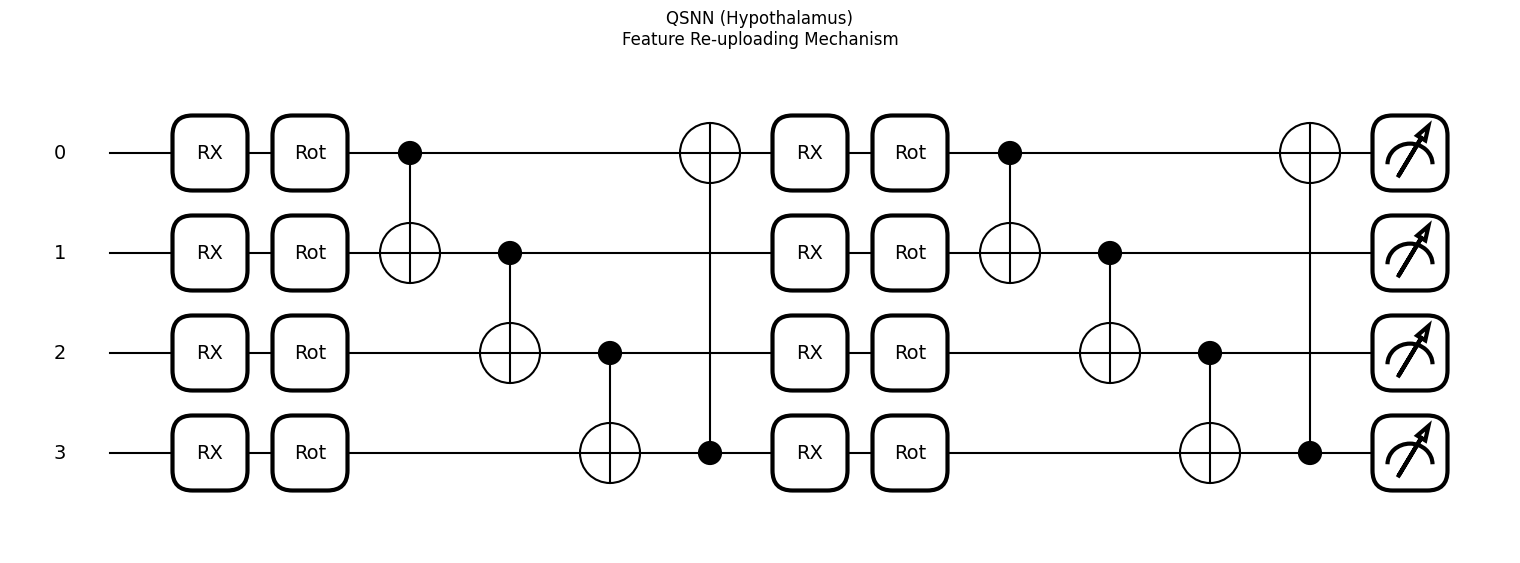


--- QLSTM: Controlled Gating Architecture ---


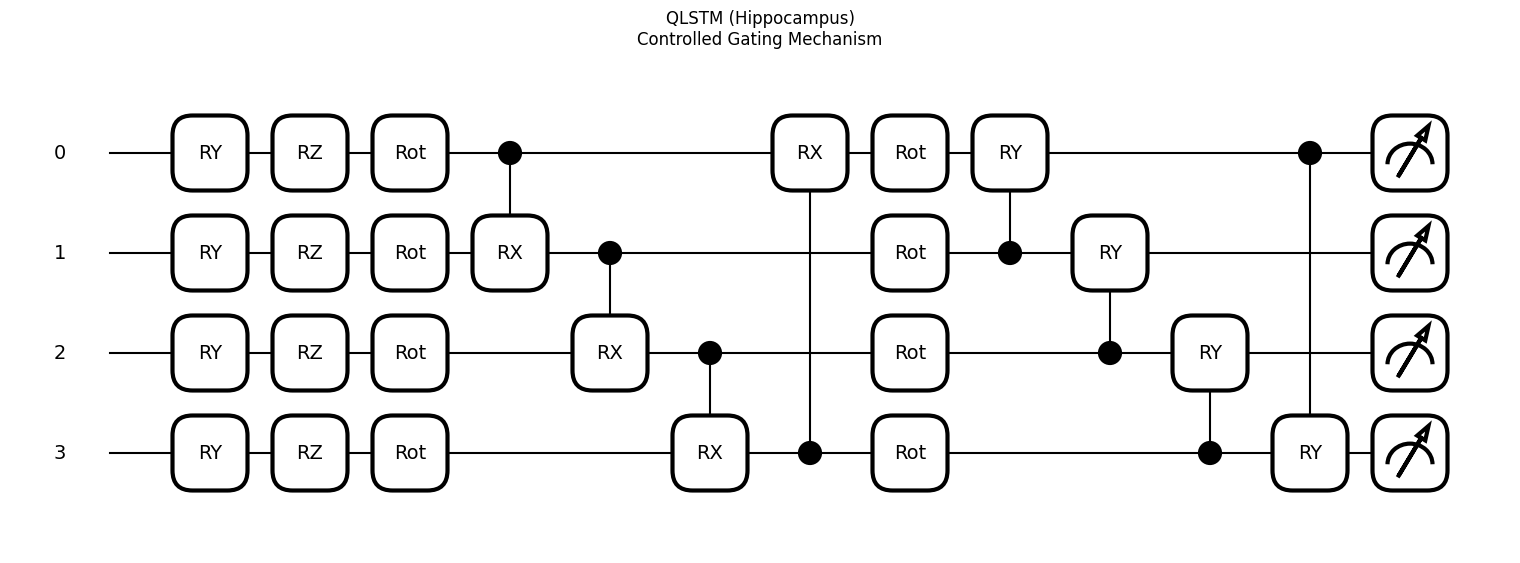

In [13]:
def draw_detailed_circuits():
    print("Generating Detailed Architecture Diagrams...")
    
    # Dummy data
    x = torch.tensor([0.1, 0.2, 0.3, 0.4])
    # Weights matching the new shapes
    w_qsnn = torch.rand(2, n_qubits, 3)
    w_qlstm = torch.rand(3, n_qubits, 3)

    # 1. Draw QSNN (Re-uploading)
    print("\n--- QSNN: Data Re-uploading Architecture ---")
    fig, ax = qml.draw_mpl(qsnn_circuit)(x, w_qsnn)
    plt.title("QSNN (Hypothalamus)\nFeature Re-uploading Mechanism")
    plt.show()

    # 2. Draw QLSTM (Gated)
    print("\n--- QLSTM: Controlled Gating Architecture ---")
    fig, ax = qml.draw_mpl(qlstm_circuit)(x, w_qlstm)
    plt.title("QLSTM (Hippocampus)\nControlled Gating Mechanism")
    plt.show()

draw_detailed_circuits()